In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
fireball = pd.read_csv('fireballs.csv',skiprows=[1])
#fireball
fireball = fireball.rename(columns={
    "Velocity Components (km/s)": "Velocity (X-component)(km/s)",
    "Unnamed: 5": "Velocity (Y-component)(km/s)",
    "Unnamed: 6": "Velocity (Z-component)(km/s)"
})

In [4]:
# Basic structure of the dataset
print("Shape:", fireball.shape) # (rows, columns)
print("\nColumn names:") #column names
print(fireball.columns.tolist())

print("\nData types:")
print(fireball.dtypes)

Shape: (1073, 9)

Column names:
['Peak Brightness Date/Time (UT)', 'Latitude (deg.)', 'Longitude (deg.)', 'Altitude (km)', 'Velocity (X-component)(km/s)', 'Velocity (Y-component)(km/s)', 'Velocity (Z-component)(km/s)', 'Total Radiated Energy (J)', 'Calculated Total Impact Energy (kt)']

Data types:
Peak Brightness Date/Time (UT)             str
Latitude (deg.)                            str
Longitude (deg.)                           str
Altitude (km)                          float64
Velocity (X-component)(km/s)           float64
Velocity (Y-component)(km/s)           float64
Velocity (Z-component)(km/s)           float64
Total Radiated Energy (J)              float64
Calculated Total Impact Energy (kt)    float64
dtype: object


In [5]:
# Example observations
fireball.head()

,Peak Brightness Date/Time (UT),Latitude (deg.),Longitude (deg.),Altitude (km),Velocity (X-component)(km/s),Velocity (Y-component)(km/s),Velocity (Z-component)(km/s),Total Radiated Energy (J),Calculated Total Impact Energy (kt)
0,2026-09-15 11:26:13,37.6S,161.6W,37.0,NaN,NaN,NaN,2.200000e+10,0.079
1,2026-09-11 10:18:03,0.2S,129.6W,70.0,NaN,NaN,NaN,6.100000e+10,0.200
2,2026-09-11 01:12:11,54.4N,100.1W,38.0,NaN,NaN,NaN,2.460000e+11,0.670
3,2026-09-10 05:22:22,19.3S,28.1W,33.6,-14.6,6.4,10.9,1.110000e+11,0.330
4,2026-08-15 07:32:40,4.0N,115.4W,37.0,NaN,NaN,NaN,3.900000e+10,0.130


In [6]:
# Missing values in every column
missing_all = pd.DataFrame({
    "missing_count": fireball.isna().sum(),
    "missing_percentage": fireball.isna().mean() * 100
})

missing_all

,missing_count,missing_percentage
Peak Brightness Date/Time (UT),0,0.000000
Latitude (deg.),186,17.334576
Longitude (deg.),186,17.334576
Altitude (km),472,43.988816
Velocity (X-component)(km/s),712,66.356011
Velocity (Y-component)(km/s),712,66.356011
Velocity (Z-component)(km/s),712,66.356011
Total Radiated Energy (J),0,0.000000
Calculated Total Impact Energy (kt),0,0.000000


In [7]:

total_observations = len(fireball)

altitude_available = fireball["Altitude (km)"].notna().sum()

complete_velocity = (
    fireball[
        [
            "Velocity (X-component)(km/s)",
            "Velocity (Y-component)(km/s)",
            "Velocity (Z-component)(km/s)"
        ]
    ]
    .notna()
    .all(axis=1)
    .sum()
)

altitude_and_velocity = (
    fireball[
        [
            "Altitude (km)",
            "Velocity (X-component)(km/s)",
            "Velocity (Y-component)(km/s)",
            "Velocity (Z-component)(km/s)"
        ]
    ]
    .notna()
    .all(axis=1)
    .sum()
)

print("Total observations:", total_observations)
print("Observations with altitude:", altitude_available)
print("Observations with complete velocity:", complete_velocity)
print(
    "Observations with altitude and complete velocity:",
    altitude_and_velocity
)

Total observations: 1073
Observations with altitude: 601
Observations with complete velocity: 361
Observations with altitude and complete velocity: 358


 Initial Dataset Inspection

The dataset contains 1,073 observations and 9 variables. The initial inspection included the dataset dimensions, column names, data types, example records, and missing values. Missing data is concentrated mainly in the location, altitude, and velocity measurements. Latitude and longitude are each missing for 186 observations (17.33%), altitude is missing for 472 observations (43.99%), and the three velocity components each contain 712 missing values (66.36%). Of the 1,073 total observations, 601 have altitude measurements, 361 have complete velocity data for all three velocity components, and 358 contain both altitude and complete velocity data. Missing observations were retained rather than immediately removing incomplete rows, since the availability of altitude, location, and velocity measurements varies between events and different stages of the analysis may require different subsets of the dataset.

### Data cleaning
For the purposes of the machine learning model, there seems to be little value for latitude, longitude and peak brightness. It's better to begin without them.  But, for the sake of it, let's convert the values here. Use a copy of the original dataframe, helps if we later need to go back to it.

In [8]:
# latitude and longitude conversion helper function
def parse_coord(s):
    # Remove whitespace and get the cardinal direction letter if present
    s = s.str.strip()
    direction = s.str.extract(r'([NSEWnsew])$', expand=False)

    # Convert the numeric part to float
    val = pd.to_numeric(s.str.replace(r'[NSEWnsew]$', '', regex=True))

    # Multiply by -1 for South and West
    return val.where(~direction.str.upper().isin(['S', 'W']), -val)

In [9]:
fireball_converted = fireball.copy()
fireball_converted["Peak Brightness Date/Time (UT)"] = pd.to_datetime(fireball["Peak Brightness Date/Time (UT)"], format='%Y-%m-%d %H:%M:%S')
fireball_latitude = parse_coord(fireball["Latitude (deg.)"])
fireball_longitude = parse_coord(fireball["Longitude (deg.)"])
fireball_converted["Latitude (deg.)"] = fireball_latitude
fireball_converted["Longitude (deg.)"] = fireball_longitude

fireball_converted
# fireball

,Peak Brightness Date/Time (UT),Latitude (deg.),Longitude (deg.),Altitude (km),Velocity (X-component)(km/s),Velocity (Y-component)(km/s),Velocity (Z-component)(km/s),Total Radiated Energy (J),Calculated Total Impact Energy (kt)
0,2026-09-15 11:26:13,-37.6,-161.6,37.0,NaN,NaN,NaN,2.200000e+10,0.079
1,2026-09-11 10:18:03,-0.2,-129.6,70.0,NaN,NaN,NaN,6.100000e+10,0.200
2,2026-09-11 01:12:11,54.4,-100.1,38.0,NaN,NaN,NaN,2.460000e+11,0.670
3,2026-09-10 05:22:22,-19.3,-28.1,33.6,-14.6,6.4,10.9,1.110000e+11,0.330
4,2026-08-15 07:32:40,4.0,-115.4,37.0,NaN,NaN,NaN,3.900000e+10,0.130
...,...,...,...,...,...,...,...,...,...
1068,1993-11-29 17:48:41,26.5,78.3,NaN,NaN,NaN,NaN,2.600000e+10,0.092
1069,1993-10-31 03:39:27,51.3,-100.9,NaN,NaN,NaN,NaN,4.000000e+10,0.130
1070,1991-10-04 09:22:47,78.7,6.3,NaN,NaN,NaN,NaN,5.500000e+11,1.400
1071,1990-10-01 03:51:47,7.5,142.8,NaN,NaN,NaN,NaN,2.500000e+12,5.200


In [19]:
# These can be used for the main models

fireball_converted["Velocity Magnitude (km/s)"] = np.sqrt(
    fireball_converted["Velocity (X-component)(km/s)"]**2
    + fireball_converted["Velocity (Y-component)(km/s)"]**2
    + fireball_converted["Velocity (Z-component)(km/s)"]**2
)
fireball_converted["Log10 Impact Energy (kt)"] = np.log10(
    fireball_converted["Calculated Total Impact Energy (kt)"]
)

fireball_converted["Log10 Radiated Energy (J)"] = np.log10(
    fireball_converted["Total Radiated Energy (J)"]
)


fireball_ml = fireball_converted[
    [
        "Altitude (km)",
        "Velocity (X-component)(km/s)",
        "Velocity (Y-component)(km/s)",
        "Velocity (Z-component)(km/s)",
        "Velocity Magnitude (km/s)",
        "Total Radiated Energy (J)",
        "Log10 Radiated Energy (J)",
        "Calculated Total Impact Energy (kt)",
        "Log10 Impact Energy (kt)"
    ]
]

fireball_ml_simple = fireball_ml.dropna()

fireball_ml_simple

,Altitude (km),Velocity (X-component)(km/s),Velocity (Y-component)(km/s),Velocity (Z-component)(km/s),Velocity Magnitude (km/s),Total Radiated Energy (J),Log10 Radiated Energy (J),Calculated Total Impact Energy (kt),Log10 Impact Energy (kt)
3,33.6,-14.6,6.4,10.9,19.311396,1.110000e+11,11.045323,0.33,-0.481486
5,30.0,5.2,22.3,0.2,22.899127,3.800000e+10,10.579784,0.13,-0.886057
10,31.5,14.4,-6.5,1.0,15.830666,3.500000e+10,10.544068,0.12,-0.920819
11,32.7,-13.0,18.7,2.1,22.871379,6.000000e+10,10.778151,0.19,-0.721246
12,36.0,-1.8,24.1,-5.4,24.763077,6.400000e+10,10.806180,0.20,-0.698970
...,...,...,...,...,...,...,...,...,...
800,29.6,8.5,-12.1,-6.8,16.275749,6.240000e+11,11.795185,1.50,0.176091
801,35.0,10.5,-23.2,-2.9,25.630060,4.330000e+11,11.636488,1.10,0.041393
812,23.0,14.8,-8.7,10.4,20.072120,5.180000e+11,11.714330,1.30,0.113943
817,26.0,-1.0,-5.4,-17.3,18.150758,2.150000e+12,12.332438,4.60,0.662758


### Notes on imputation
- There's a good chance the data is "Missing Not At Random", meaning the fireballs were too weak to track properly
- If imputing, use Multivariate Imputation by Chained Equations (MICE) (scikit IterativeImputer) combined with Missingness Indicator Flags (was data present or was it imputated).

Impact Energy Summary:


,Calculated Total Impact Energy (kt),Log10 Impact Energy (kt)
count,358.000000,358.000000
mean,2.396436,-0.471361
std,23.560376,0.576343
min,0.048000,-1.318759
25%,0.130000,-0.886057
50%,0.240000,-0.619789
75%,0.557500,-0.253768
max,441.000000,2.644439


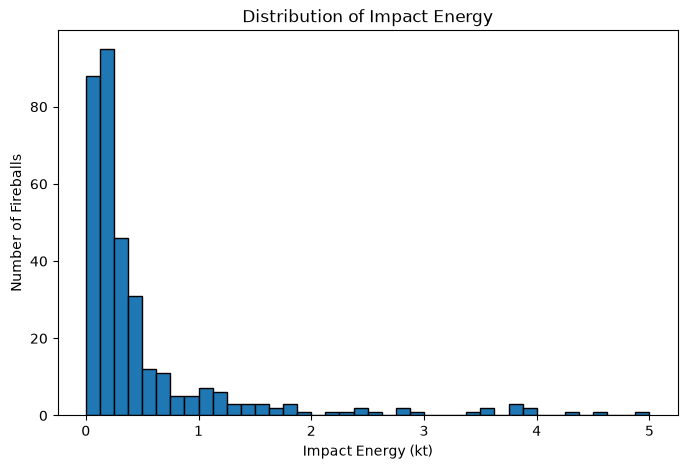

Note: 18 observations above 5 kt are not shown in this histogram. The plot is restricted to 0 - 5 kt so that the distribution of the majority of fireballs can be examined clearly. The higher-energy observations remain in the dataset and are not removed from the analysis.


,Altitude (km),Velocity (X-component)(km/s),Velocity (Y-component)(km/s),Velocity (Z-component)(km/s),Velocity Magnitude (km/s),Calculated Total Impact Energy (kt),Log10 Impact Energy (kt)
483,23.3,12.8,-13.3,-2.4,18.614242,441.0,2.644439
282,26.0,6.3,-3.0,-31.2,31.970768,49.0,1.690196
603,19.1,14.0,-16.0,-6.0,22.090722,33.0,1.518514
596,38.0,3.0,-17.0,27.0,32.046841,20.0,1.301030
778,35.0,-15.3,1.0,11.6,19.226284,18.0,1.255273
577,26.0,12.1,10.0,0.2,15.698726,14.0,1.146128
689,26.5,4.9,-15.0,1.6,15.860958,14.0,1.146128
380,31.0,2.7,14.5,5.0,15.573696,13.0,1.113943
200,35.5,-2.6,5.9,-12.1,13.710580,12.0,1.079181
479,21.2,1.0,9.0,-8.0,12.083046,9.8,0.991226


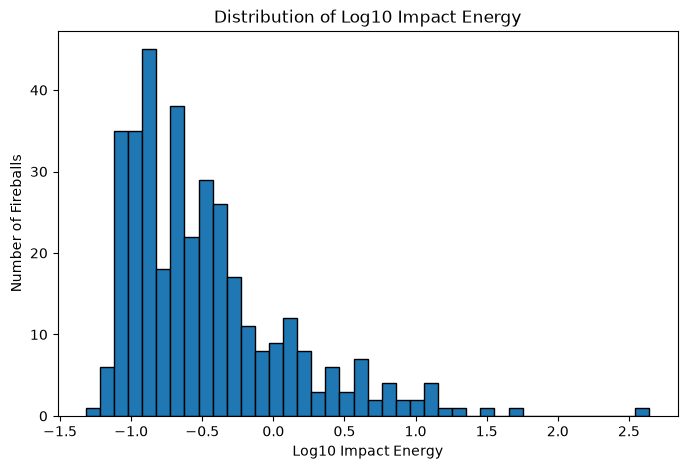

In [11]:
print("Impact Energy Summary:")
display(
    fireball_ml_simple[
        ["Calculated Total Impact Energy (kt)", "Log10 Impact Energy (kt)"]
    ].describe()
)
plt.figure(figsize=(8, 5))

plt.hist(
    fireball_ml_simple["Calculated Total Impact Energy (kt)"],
    bins=40,
    range=(0, 5),
    edgecolor="black"
)

plt.xlabel("Impact Energy (kt)")
plt.ylabel("Number of Fireballs")
plt.title("Distribution of Impact Energy")

plt.show()
fireball_ml_simple["Calculated Total Impact Energy (kt)"].sort_values(ascending=False).head(10)
above_5 = (
    fireball_ml_simple["Calculated Total Impact Energy (kt)"] > 5
).sum()

print(
    f"Note: {above_5} observations above 5 kt are not shown in this histogram. "
    "The plot is restricted to 0 - 5 kt so that the distribution of the majority "
    "of fireballs can be examined clearly. The higher-energy observations remain "
    "in the dataset and are not removed from the analysis."
)
high_energy_fireballs = fireball_ml_simple[
    fireball_ml_simple["Calculated Total Impact Energy (kt)"] > 5
].sort_values(
    by="Calculated Total Impact Energy (kt)",
    ascending=False
)

display(high_energy_fireballs)

plt.figure(figsize=(8, 5))

plt.hist(
    fireball_ml_simple["Log10 Impact Energy (kt)"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Log10 Impact Energy")
plt.ylabel("Number of Fireballs")
plt.title("Distribution of Log10 Impact Energy")

plt.show()

Now I shall make three scatter plots: altitude vs log impact energy, velocity magnitude vs log impact energy, and altitude vs velocity magnitude. I shall use  log impact energy rather than raw impact energy here because we  already showed that raw impact energy is extremely right-skewed and dominated by a handful of extreme events.

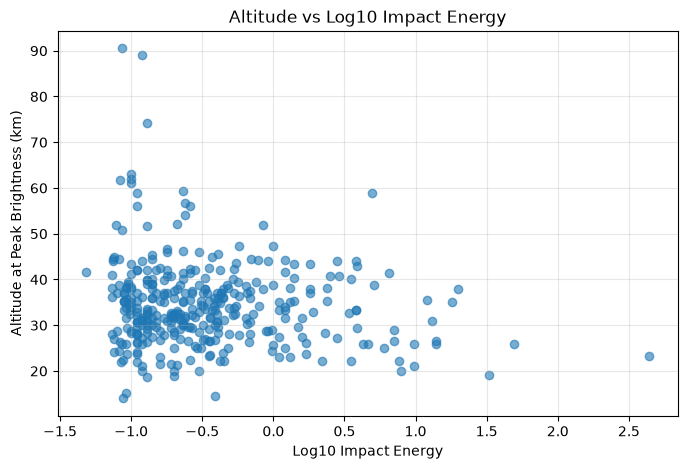

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    fireball_ml_simple["Log10 Impact Energy (kt)"],
    fireball_ml_simple["Altitude (km)"],
    alpha=0.6
)

plt.xlabel("Log10 Impact Energy")
plt.ylabel("Altitude at Peak Brightness (km)")
plt.title("Altitude vs Log10 Impact Energy")

plt.grid(alpha=0.3)
plt.show()

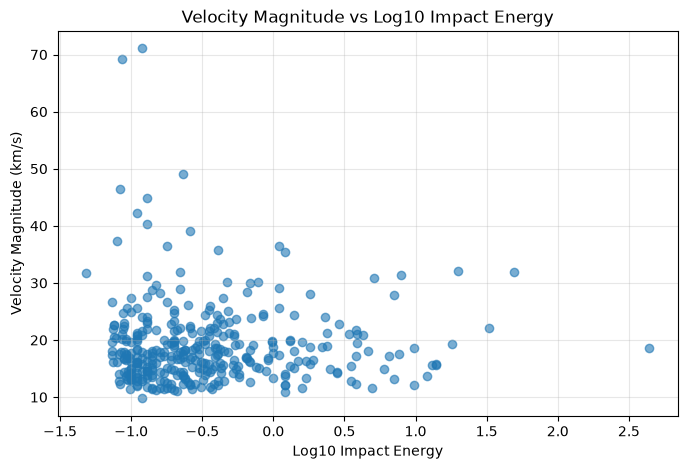

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    fireball_ml_simple["Log10 Impact Energy (kt)"],
    fireball_ml_simple["Velocity Magnitude (km/s)"],
    alpha=0.6
)

plt.xlabel("Log10 Impact Energy")
plt.ylabel("Velocity Magnitude (km/s)")
plt.title("Velocity Magnitude vs Log10 Impact Energy")

plt.grid(alpha=0.3)
plt.show()

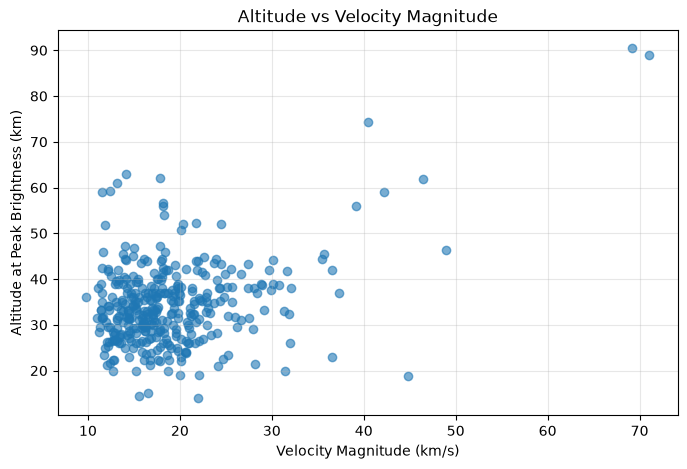

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    fireball_ml_simple["Velocity Magnitude (km/s)"],
    fireball_ml_simple["Altitude (km)"],
    alpha=0.6
)

plt.xlabel("Velocity Magnitude (km/s)")
plt.ylabel("Altitude at Peak Brightness (km)")
plt.title("Altitude vs Velocity Magnitude")

plt.grid(alpha=0.3)
plt.show()

In [15]:
pairs = [
    ("Altitude (km)", "Log10 Impact Energy (kt)"),
    ("Velocity Magnitude (km/s)", "Log10 Impact Energy (kt)"),
    ("Altitude (km)", "Velocity Magnitude (km/s)")
]

for x, y in pairs:
    pearson = fireball_ml_simple[x].corr(
        fireball_ml_simple[y],
        method="pearson"
    )

    spearman = fireball_ml_simple[x].corr(
        fireball_ml_simple[y],
        method="spearman"
    )

    print(f"{x} vs {y}")
    print(f"  Pearson:  {pearson:.3f}")
    print(f"  Spearman: {spearman:.3f}")
    print()

Altitude (km) vs Log10 Impact Energy (kt)
  Pearson:  -0.142
  Spearman: -0.078

Velocity Magnitude (km/s) vs Log10 Impact Energy (kt)
  Pearson:  -0.009
  Spearman: 0.025

Altitude (km) vs Velocity Magnitude (km/s)
  Pearson:  0.392
  Spearman: 0.144



In [16]:
pairs_raw = [
    ("Altitude (km)", "Calculated Total Impact Energy (kt)"),
    ("Velocity Magnitude (km/s)", "Calculated Total Impact Energy (kt)")
]

for x, y in pairs_raw:
    pearson = fireball_ml_simple[x].corr(
        fireball_ml_simple[y],
        method="pearson"
    )

    spearman = fireball_ml_simple[x].corr(
        fireball_ml_simple[y],
        method="spearman"
    )

    print(f"{x} vs {y}")
    print(f"  Pearson:  {pearson:.3f}")
    print(f"  Spearman: {spearman:.3f}")
    print()

Altitude (km) vs Calculated Total Impact Energy (kt)
  Pearson:  -0.081
  Spearman: -0.078

Velocity Magnitude (km/s) vs Calculated Total Impact Energy (kt)
  Pearson:  0.010
  Spearman: 0.025



Pearson seems to show stronger correlation for altitude vs velocity due to the outliers

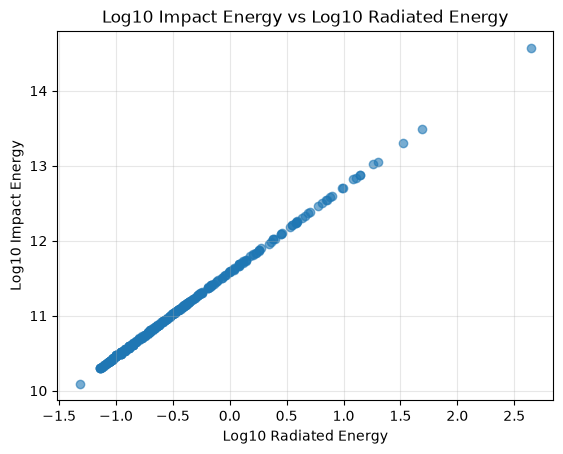

In [43]:
# plt.figure(figsize=(8, 5))

plt.scatter(
    fireball_ml_simple["Log10 Impact Energy (kt)"],
    fireball_ml_simple["Log10 Radiated Energy (J)"],
    alpha=0.6
)

plt.xlabel("Log10 Radiated Energy")
plt.ylabel("Log10 Impact Energy")
plt.title("Log10 Impact Energy vs Log10 Radiated Energy")

plt.grid(alpha=0.3)
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = fireball_ml_simple[["Log10 Radiated Energy (J)"]]
y = fireball_ml_simple[["Log10 Impact Energy (kt)"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

fireball_ml_simple[["Log10 Radiated Energy (J)"]]

,Log10 Radiated Energy (J)
3,11.045323
5,10.579784
10,10.544068
11,10.778151
12,10.806180
...,...
800,11.795185
801,11.636488
812,11.714330
817,12.332438


In [37]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Intercept (b): {model.intercept_[0]:.4f}")
print(f"Model Slope (m):     {model.coef_[0][0]:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score:                        {r2:.4f}")

Model Intercept (b): -10.2632
Model Slope (m):     0.8859
Root Mean Squared Error (RMSE): 0.0061
R² Score:                        0.9999


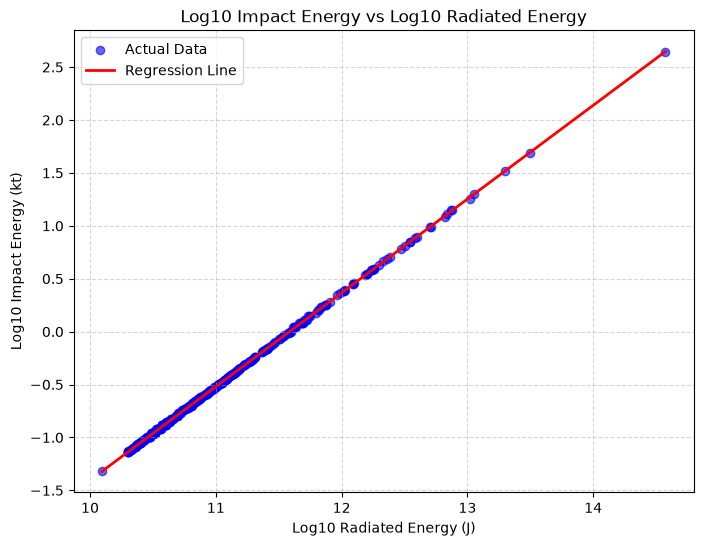

In [44]:
plt.figure(figsize=(8, 6))

# Plot actual data points (using full dataset for visualization)
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')

# Generate a smooth line across the range of X values for the prediction line
X_line = pd.DataFrame(
    np.linspace(X.min().values[0], X.max().values[0], 100),
    columns=X.columns
)
y_line = model.predict(X_line)

# Plot the regression line
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Log10 Radiated Energy (J)')
plt.ylabel('Log10 Impact Energy (kt)')
plt.title("Log10 Impact Energy vs Log10 Radiated Energy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

There's practically a perfect linear relationship between impact energy and radiated energy.